# EDA · Predicción de Entregas Tardías en Supply Chain

**Dataset:** SCMS Delivery History (10.324 órdenes)
**Objetivo:** explorar patrones que expliquen las entregas tardías y preparar features para el modelo de ML.

**Hallazgo previo (Fase 1):** clase desbalanceada — 88,5% a tiempo vs 11,5% tarde.

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo visual consistente
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

# Cargar la tabla ya enriquecida desde la Fase 1
con = duckdb.connect('../supply_chain.duckdb')
df = con.execute("SELECT * FROM orders_ml").df()
con.close()

print(f"Registros: {df.shape[0]:,} · Columnas: {df.shape[1]}")
df.head()

Registros: 10,324 · Columnas: 35


,id,project_code,pq,po_so,asndn,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,...,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_kilograms,freight_cost_usd,line_item_insurance_usd,dias_entrega,entrega_tarde
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN,0,0
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,6200.0,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN,0,0
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN,0,0
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN,0,0
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,121600.0,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN,0,0


## 1. Calidad de datos: valores nulos

In [2]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Columnas con valores nulos:")
print(nulos)

Columnas con valores nulos:
line_item_insurance_usd    287
dtype: int64


## 2. Distribución de la variable objetivo

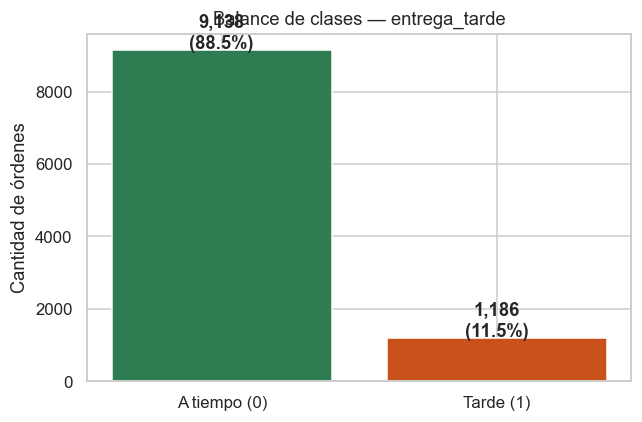

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['entrega_tarde'].value_counts().sort_index()
bars = ax.bar(['A tiempo (0)', 'Tarde (1)'], counts.values,
              color=['#2e7d52', '#c8521a'])
ax.set_title('Balance de clases — entrega_tarde')
ax.set_ylabel('Cantidad de órdenes')
for bar, val in zip(bars, counts.values):
    pct = 100 * val / counts.sum()
    ax.text(bar.get_x() + bar.get_width()/2, val + 50,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Distribución de días de entrega

Valores negativos = entrega adelantada · positivos = entrega tardía.

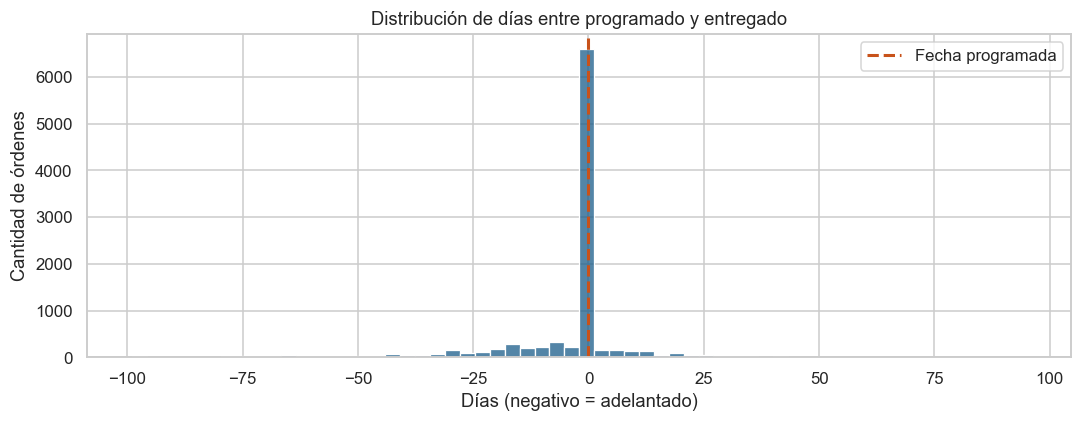

count    10324.0
mean        -6.0
std         27.2
min       -372.0
25%         -3.0
50%          0.0
75%          0.0
max        192.0
Name: dias_entrega, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
# Recorto a un rango razonable para visualizar mejor (hay outliers extremos)
datos = df[(df['dias_entrega'] > -100) & (df['dias_entrega'] < 100)]
sns.histplot(datos['dias_entrega'], bins=60, color='#1a5c8a', ax=ax)
ax.axvline(0, color='#c8521a', linestyle='--', linewidth=2, label='Fecha programada')
ax.set_title('Distribución de días entre programado y entregado')
ax.set_xlabel('Días (negativo = adelantado)')
ax.set_ylabel('Cantidad de órdenes')
ax.legend()
plt.tight_layout()
plt.savefig('dist_dias_entrega.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['dias_entrega'].describe().round(1))

### Observación clave
La distribución se concentra fuertemente en 0 (mediana = 0): la mayoría de
las órdenes se entregan en fecha. Existen outliers extremos (min -372, max 192 días)
que probablemente son errores de carga de fechas, no entregas reales. La variable
objetivo `entrega_tarde` (>0 días) no se ve afectada por estos outliers negativos,
ya que solo marca atrasos.

## 4. Tasa de tardanza por modo de envío y por país

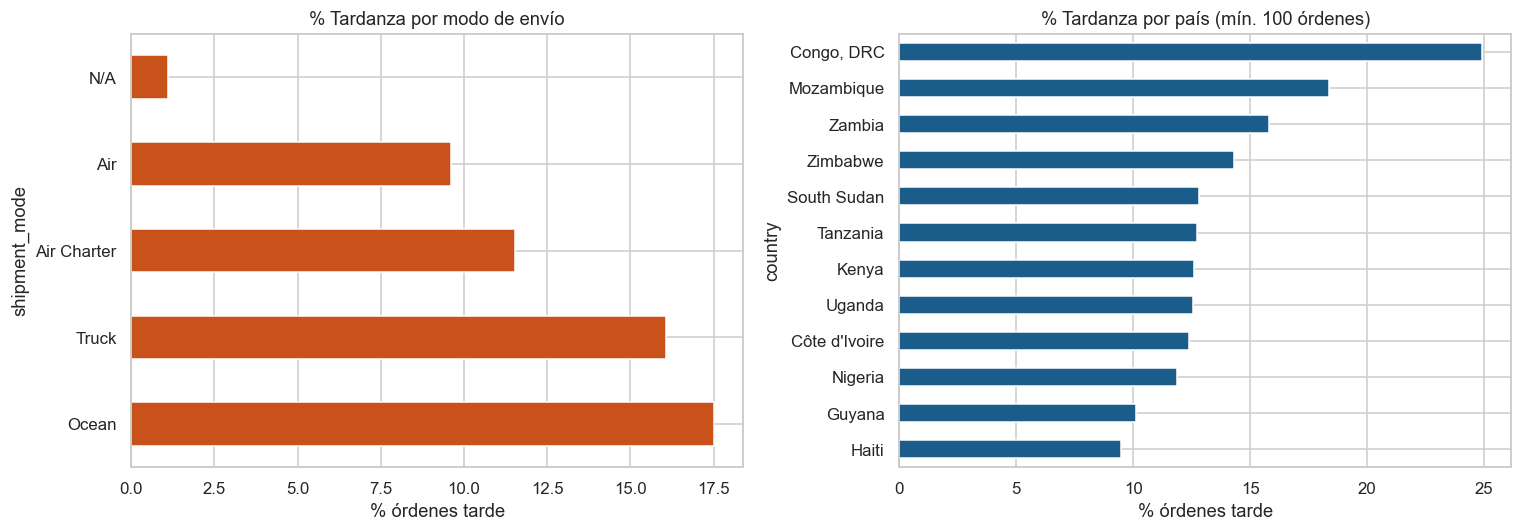

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por modo de envío
tardanza_modo = df.groupby('shipment_mode')['entrega_tarde'].mean().sort_values(ascending=False) * 100
tardanza_modo.plot(kind='barh', ax=axes[0], color='#c8521a')
axes[0].set_title('% Tardanza por modo de envío')
axes[0].set_xlabel('% órdenes tarde')

# Top 12 países por tasa de tardanza (con mínimo de órdenes para que sea representativo)
paises = df.groupby('country').agg(
    total=('entrega_tarde', 'count'),
    pct_tarde=('entrega_tarde', 'mean')
)
paises = paises[paises['total'] >= 100].sort_values('pct_tarde', ascending=False).head(12)
(paises['pct_tarde'] * 100).plot(kind='barh', ax=axes[1], color='#1a5c8a')
axes[1].set_title('% Tardanza por país (mín. 100 órdenes)')
axes[1].set_xlabel('% órdenes tarde')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('tardanza_modo_pais.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlaciones entre variables numéricas

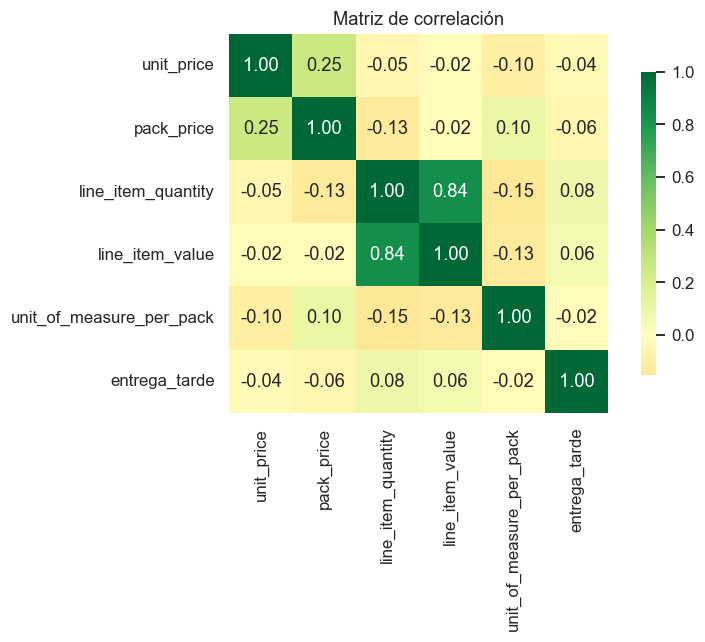

In [10]:
num_cols = ['unit_price', 'pack_price', 'line_item_quantity',
            'line_item_value', 'unit_of_measure_per_pack', 'entrega_tarde']
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones del EDA

1. **Variables categóricas son las predictoras fuertes:** modo de envío (Ocean/Truck
   con mayor atraso) y país destino (Congo DRC, Mozambique, Zambia lideran las demoras).
2. **Variables numéricas tienen baja correlación lineal** con el atraso (-0.06 a 0.08).
   El Random Forest capturará relaciones no lineales e interacciones entre features.
3. **Multicolinealidad detectada:** `line_item_quantity` y `line_item_value` correlacionan
   0.84 → se usará solo una para evitar redundancia.
4. Features seleccionadas para el modelo: shipment_mode, country, vendor,
   sub_classification, product_group, unit_price, line_item_quantity.